Original: m=-2.5092, b=9.0143
Custom LSM: m=-2.4905, b=9.4671
Numpy polyfit: m=-2.4905, b=9.4671
Largest residual at index 67: 0.5216
Smallest residual at index 22: -0.0008


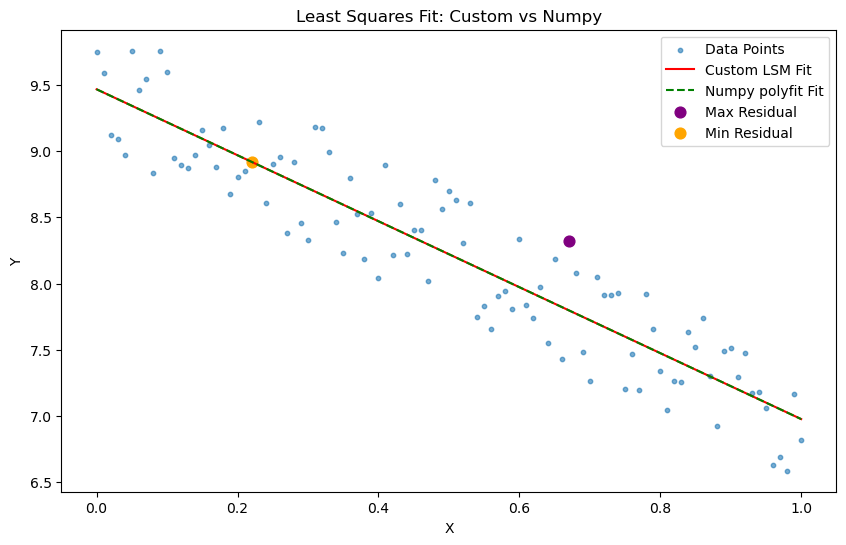

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  
m_true = np.random.uniform(-10, 10)
b_true = np.random.uniform(-10, 10)
noise = np.random.uniform(0, 1, 101)

X = np.arange(0, 1.01, 0.01)
Y = m_true * X + b_true + noise

sort_idx = np.argsort(X)
X = X[sort_idx]
Y = Y[sort_idx]

def least_squares(X, Y):
    n = len(X)
    x_mean = np.mean(X)
    y_mean = np.mean(Y)
    numerator = np.sum((X - x_mean) * (Y - y_mean))
    denominator = np.sum((X - x_mean) ** 2)
    m = numerator / denominator
    b = y_mean - m * x_mean
    return m, b

m_lsm, b_lsm = least_squares(X, Y)

m_np, b_np = np.polyfit(X, Y, 1)

Y_pred = m_lsm * X + b_lsm
residuals = Y - Y_pred

max_residual_idx = np.argmax(np.abs(residuals))
min_residual_idx = np.argmin(np.abs(residuals))

print(f"Original: m={m_true:.4f}, b={b_true:.4f}")
print(f"Custom LSM: m={m_lsm:.4f}, b={b_lsm:.4f}")
print(f"Numpy polyfit: m={m_np:.4f}, b={b_np:.4f}")
print(f"Largest residual at index {max_residual_idx}: {residuals[max_residual_idx]:.4f}")
print(f"Smallest residual at index {min_residual_idx}: {residuals[min_residual_idx]:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(X, Y, label='Data Points', alpha=0.6, s=10)
plt.plot(X, Y_pred, color='red', label='Custom LSM Fit')
plt.plot(X, m_np * X + b_np, color='green', linestyle='--', label='Numpy polyfit Fit')
plt.scatter(X[max_residual_idx], Y[max_residual_idx], color='purple', s=60, label='Max Residual')
plt.scatter(X[min_residual_idx], Y[min_residual_idx], color='orange', s=60, label='Min Residual')
plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Least Squares Fit: Custom vs Numpy')
plt.show()